# De la détection satellite à la perte estimée en € — EMSR664 (Émilie-Romagne, mai 2023)

Ce notebook prend la suite de `03_flood_detection_italy.ipynb` (masque de zone inondée déjà calculé) et referme la boucle complète du cat model :

```
Hazard (notre masque satellite) × Exposure (LitPop) × Vulnerability (JRC) = Loss (€)
```

**Différence importante avec le premier notebook de test ("hello world" Floride)** : ici on a UN SEUL événement réel et déterministe (pas 216 scénarios probabilistes). Donc pas de courbe de dépassement ni de perte annuelle moyenne — juste : *"si cet événement se reproduit tel quel, quelle perte ?"*.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import ee
import numpy as np
from shapely.geometry import box

from climada.entity import LitPop, ImpactFuncSet
from climada.hazard import Hazard, Centroids
from climada.engine import ImpactCalc
from climada_petals.entity.impact_funcs.river_flood import ImpfRiverFlood

PROJECT_ID = "zeta-bonfire-478712-n9"
ee.Initialize(project=PROJECT_ID)

# Même zone que le notebook 03
aoi_ee = ee.Geometry.Rectangle([11.55, 44.05, 12.30, 44.45])
aoi_shapely = box(11.55, 44.05, 12.30, 44.45)  # même rectangle, format shapely pour CLIMADA

print("Imports OK")

Imports OK


## 1. Reconstruire le masque d'inondation, avec filtrage anti-bruit

Le premier essai a détecté "au moins un pixel inondé" dans les 180/180 cellules de la zone — improbable pour une vraie crue localisée, révélateur de **bruit radar (speckle)**, un phénomène de grain aléatoire propre à l'imagerie SAR (interférence du signal réfléchi). Deux corrections standards en télédétection SAR :
1. **Lissage spatial** (`focal_median`) sur les images avant/après, avant de calculer la différence — réduit le bruit pixel par pixel.
2. **Filtre de surface minimale connexe** (*Minimum Mapping Unit*) — élimine les taches isolées de quelques pixels qui ne peuvent pas être une vraie inondation (trop petites, non connectées à une zone plus large).

In [2]:
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi_ee)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .select("VV")
)


def filtrer_speckle(img, rayon_m=50):
    """Lissage spatial (moyenne mobile) pour réduire le bruit speckle propre au radar."""
    return img.focal_median(radius=rayon_m, units="meters")


img_avant = filtrer_speckle(s1.filterDate("2023-04-15", "2023-05-02").median()).clip(aoi_ee)
img_apres = filtrer_speckle(s1.filterDate("2023-05-17", "2023-05-24").median()).clip(aoi_ee)

SEUIL_DB = -3
masque_brut = img_apres.subtract(img_avant).lt(SEUIL_DB)

# Filtre de surface minimale connexe : ne garde que les taches d'au moins N pixels connectés
SURFACE_MIN_PIXELS = 20  # à ~10 m/pixel natif, ~2000 m² minimum pour être retenu comme "vraie" inondation
taille_tache = masque_brut.selfMask().connectedPixelCount(maxSize=100, eightConnected=True)
masque_inondation = masque_brut.updateMask(taille_tache.gte(SURFACE_MIN_PIXELS)).unmask(0)

print("Masque recalculé (avec filtrage anti-bruit)")

Masque recalculé (avec filtrage anti-bruit)


## 2. Construire l'Exposure (LitPop) sur la zone

**Ajustement par rapport au plan initial** : `LitPop.from_shape_and_countries` (calcul depuis les données brutes) nécessite un fichier de population mondiale (GPW) qui demande un compte NASA Earthdata — pas envisageable en automatique. On utilise à la place `client.get_litpop(...)`, qui télécharge une version **déjà calculée** par CLIMADA via son propre service de données (mêmes paramètres : `fin_mode="pc"`, produced capital Banque Mondiale, résolution native ~150 arc-sec, environ 4,6 km). Résolution plus grossière que prévu initialement (~1 km), mais aucun compte externe à créer et un ordre de grandeur qui reste tout à fait exploitable pour ce niveau d'analyse. On télécharge la couche pour l'Italie entière puis on la découpe à notre zone d'intérêt.

2026-08-24 17:22:58,422 - climada.util.api_client - WARNING - there is no internet connection but the client has stored the results of this very request sometime in the past.


Nombre de points de grille dans la zone : 180
Valeur totale exposée (produced capital) : 92,011,909,200 USD


<GeoAxes: title={'center': "LitPop Exposure for ['ITA'] at 150 as, year: 2018, financial mode: pc,\nexp: (1, 1), admin1_calc: False"}>

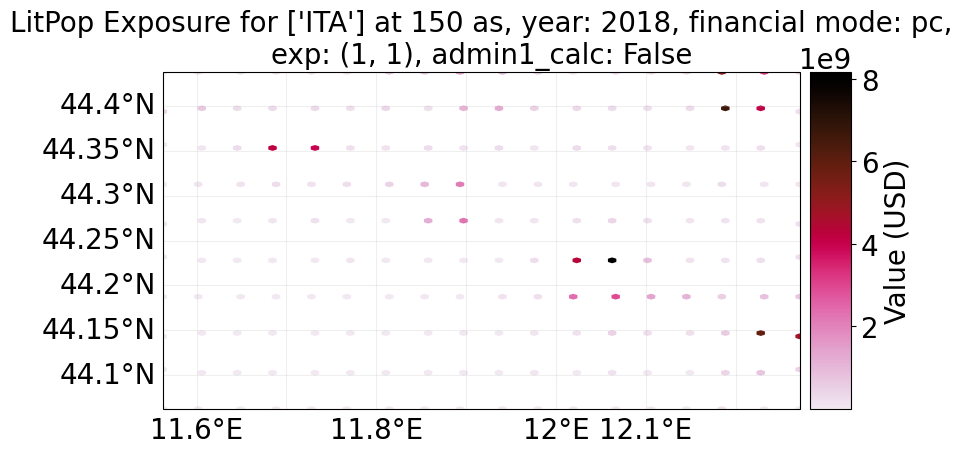

In [3]:
from climada.util.api_client import Client

client = Client()
exp_italie = client.get_litpop("Italy")

# Découpage à notre zone d'intérêt (mêmes bornes que le notebook 03)
LON_MIN, LON_MAX = 11.55, 12.30
LAT_MIN, LAT_MAX = 44.05, 44.45
exp = exp_italie.copy()
exp.data = exp.gdf.cx[LON_MIN:LON_MAX, LAT_MIN:LAT_MAX].reset_index(drop=True)

print(f"Nombre de points de grille dans la zone : {len(exp.gdf)}")
print(f"Valeur totale exposée (produced capital) : {exp.gdf['value'].sum():,.0f} USD")
exp.plot_hexbin()

## 3. Interroger le masque satellite à chaque point d'exposition

**Attention, point technique important découvert en testant** : un échantillonnage au point exact (le centre de chaque cellule LitPop) rate systématiquement les zones inondées, car celles-ci sont des bandes étroites le long des rivières alors que la grille LitPop est grossière (~4,6 km de côté par cellule, 180 cellules pour toute la zone). Une inondation de 21 km² (confirmée par un test séparé) peut très bien exister sans qu'aucun des 180 points-centres ne tombe dedans.

**Correction : au lieu du point exact, on calcule la fraction inondée de toute la cellule** (le carré de ~4,6 km × 4,6 km que ce point représente réellement dans LitPop), pas juste son centre. C'est plus représentatif de ce qu'une cellule LitPop veut dire : "l'activité économique de cette zone de 4,6×4,6 km", pas un point unique.

In [4]:
lat = exp.gdf.geometry.y.values
lon = exp.gdf.geometry.x.values

RES_ARCSEC = 150  # résolution native de client.get_litpop()
DEMI_CELLULE_DEG = (RES_ARCSEC / 3600) / 2

cellules = ee.FeatureCollection(
    [
        ee.Feature(
            ee.Geometry.Rectangle(
                [lo - DEMI_CELLULE_DEG, la - DEMI_CELLULE_DEG, lo + DEMI_CELLULE_DEG, la + DEMI_CELLULE_DEG]
            ),
            {"idx": i},
        )
        for i, (lo, la) in enumerate(zip(lon, lat))
    ]
)

# Moyenne du masque binaire (0/1) sur chaque cellule = fraction de la cellule inondée
fractions = masque_inondation.reduceRegions(
    collection=cellules, reducer=ee.Reducer.mean(), scale=30
).getInfo()

fraction_inondee = np.zeros(len(exp.gdf))
for f in fractions["features"]:
    props = f["properties"]
    fraction_inondee[props["idx"]] = props.get("mean", 0) or 0

print(f"Cellules avec au moins un pixel inondé : {(fraction_inondee > 0).sum()} / {len(fraction_inondee)}")
print(f"Fraction moyenne inondée (cellules concernées) : {fraction_inondee[fraction_inondee > 0].mean() * 100:.1f}%" if (fraction_inondee > 0).any() else "Aucune cellule concernée")

Cellules avec au moins un pixel inondé : 71 / 180
Fraction moyenne inondée (cellules concernées) : 1.3%


## 4. Construire l'objet Hazard

**Simplifications méthodologiques assumées** (à documenter dans toute restitution) :
- Notre masque satellite est binaire (inondé / pas inondé) à l'échelle du pixel Sentinel-1, il ne mesure pas de hauteur d'eau réelle. On applique une **hypothèse de profondeur uniforme** pour tout pixel détecté comme inondé.
- Cette profondeur est ensuite **pondérée par la fraction inondée de chaque cellule LitPop** (calculée à l'étape précédente) — une cellule à moitié inondée reçoit une intensité moitié moindre qu'une cellule entièrement inondée. C'est une approximation simple mais plus honnête qu'un simple tout-ou-rien à l'échelle grossière de LitPop.
- Piste d'amélioration future, hors scope de cette phase : croiser avec un modèle de terrain (DEM/HAND) pour une profondeur réaliste et spatialement variable.

In [5]:
PROFONDEUR_HYPOTHESE_M = 1.0  # hypothèse simplificatrice, à documenter dans toute restitution

intensity = fraction_inondee * PROFONDEUR_HYPOTHESE_M

centroids = Centroids.from_lat_lon(lat, lon)

from scipy import sparse

haz = Hazard(
    haz_type="RF",
    intensity=sparse.csr_matrix(intensity.reshape(1, -1)),
    centroids=centroids,
    event_id=np.array([1]),
    event_name=["EMSR664_2023-05-16"],
    frequency=np.array([1.0]),  # événement déterministe unique, pas une fréquence probabiliste
    units="m",
)
haz.check()

print("Objet Hazard construit et validé")

Objet Hazard construit et validé


## 5. Fonction de vulnérabilité (JRC, calibrée pour l'Europe)

<Axes: title={'center': 'RF 31: Flood Europe JRC Residential noPAA'}, xlabel='Intensity (m)', ylabel='Impact (%)'>

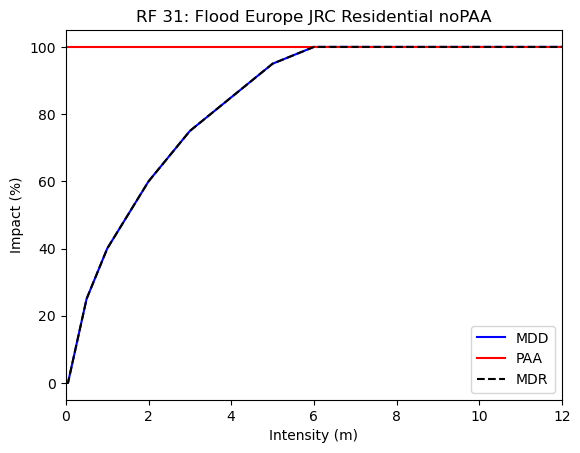

In [6]:
impf = ImpfRiverFlood.from_jrc_region_sector("Europe", sector="residential")
impf.check()

impf_set = ImpactFuncSet([impf])

# Relier chaque point d'exposition à cette fonction de vulnérabilité (id de la fonction)
exp.gdf["impf_RF"] = impf.id

impf.plot()

## 6. Calculer la perte

In [7]:
impact = ImpactCalc(exp, impf_set, haz).impact()

perte_totale = impact.at_event[0]

print(f"Perte estimée pour cet événement : {perte_totale:,.0f} USD")
print(f"(soit {perte_totale / exp.gdf['value'].sum() * 100:.2f}% de la valeur totale exposée dans la zone)")

Perte estimée pour cet événement : 18,893,148 USD
(soit 0.02% de la valeur totale exposée dans la zone)
